## Cell 1 Imports & Setup

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Load Extracted Audio Features
crema_path = "../data/processed/crema_d_audio_features.csv"
ased_path = "../data/processed/ased_audio_features.csv"

df_crema = pd.read_csv(crema_path) if os.path.exists(crema_path) else None
df_ased = pd.read_csv(ased_path) if os.path.exists(ased_path) else None

print("CREMA-D Loaded:", df_crema.shape if df_crema is not None else "Not Found")
print("ASED Loaded:", df_ased.shape if df_ased is not None else "Not Found")

CREMA-D Loaded: (7442, 28)
ASED Loaded: (2474, 28)


## Cell 2 Class Distribution & Missing Value Audit

--- CREMA-D Emotion Distribution ---
label
Anger        1271
Disgust      1271
Fear         1271
Happiness    1271
Sadness      1271
Neutral      1087
Name: count, dtype: int64


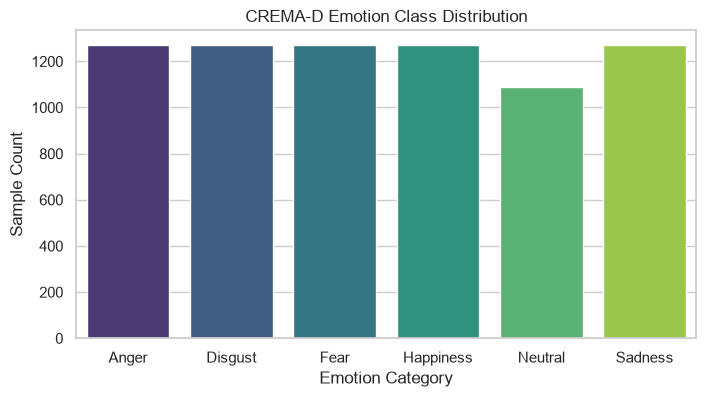


--- ASED Emotion Distribution ---
label
Neutral      522
Fear         510
Anger        486
Happiness    486
Sadness      470
Name: count, dtype: int64


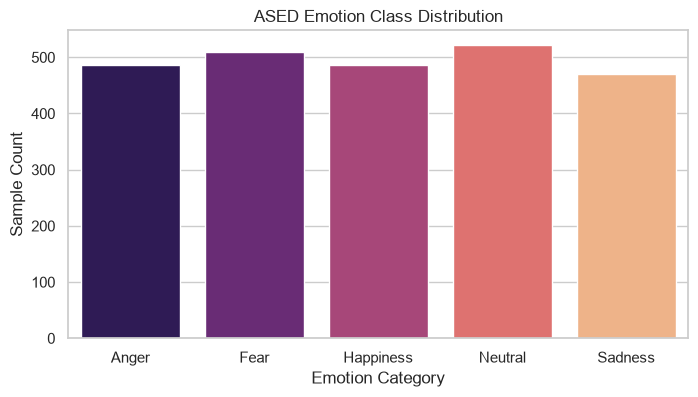

In [3]:
if df_crema is not None:
    print("--- CREMA-D Emotion Distribution ---")
    print(df_crema["label"].value_counts())
    
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df_crema, x="label", hue="label", palette="viridis", legend=False)
    plt.title("CREMA-D Emotion Class Distribution")
    plt.xlabel("Emotion Category")
    plt.ylabel("Sample Count")
    plt.show()

if df_ased is not None:
    print("\n--- ASED Emotion Distribution ---")
    print(df_ased["label"].value_counts())
    
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df_ased, x="label", hue="label", palette="magma", legend=False)
    plt.title("ASED Emotion Class Distribution")
    plt.xlabel("Emotion Category")
    plt.ylabel("Sample Count")
    plt.show()

## Cell 3 Acoustic Feature Comparison: Pitch & Energy vs. Emotion

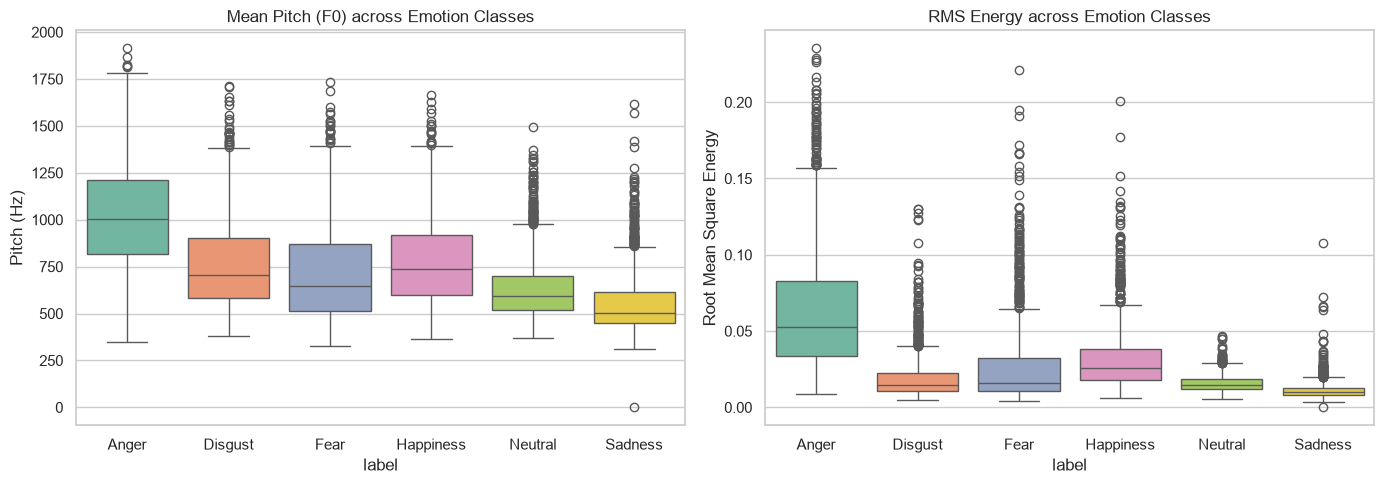

In [4]:
# Comparing Pitch (F0) and RMS Energy distributions across emotions in CREMA-D
if df_crema is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    sns.boxplot(data=df_crema, x="label", y="pitch_mean", hue="label", ax=axes[0], palette="Set2", legend=False)
    axes[0].set_title("Mean Pitch (F0) across Emotion Classes")
    axes[0].set_ylabel("Pitch (Hz)")
    
    sns.boxplot(data=df_crema, x="label", y="rmse", hue="label", ax=axes[1], palette="Set2", legend=False)
    axes[1].set_title("RMS Energy across Emotion Classes")
    axes[1].set_ylabel("Root Mean Square Energy")
    
    plt.tight_layout()
    plt.show()

In [7]:
df_crema.head(10)

,filename,dataset,label,zcr,rmse,spectral_centroid,spectral_rolloff,pitch_mean,mfcc_1,mfcc_2,...,mfcc_11,mfcc_12,mfcc_13,mfcc_14,mfcc_15,mfcc_16,mfcc_17,mfcc_18,mfcc_19,mfcc_20
0,1001_DFA_ANG_XX.wav,crema_d,Anger,0.101868,0.041986,1584.993071,3218.532986,1211.950684,-306.02740,92.670235,...,0.408197,-9.709486,-6.127124,1.737390,-14.560826,-5.176119,-2.429939,-8.718916,-6.897351,-7.056198
1,1001_DFA_DIS_XX.wav,crema_d,Disgust,0.093061,0.015996,1531.650486,3076.198630,1256.617188,-346.39963,95.839120,...,-2.534366,-7.255390,-6.153906,-3.609861,-12.719008,-3.148828,-3.569028,-8.540991,-7.949692,-3.837131
2,1001_DFA_FEA_XX.wav,crema_d,Fear,0.084286,0.045776,1489.088839,3030.215993,992.574402,-321.42026,94.760910,...,-3.357414,-8.454173,-6.561942,-2.693143,-11.711654,-5.718830,-4.945803,-8.096901,-8.022043,-6.047218
3,1001_DFA_HAP_XX.wav,crema_d,Happiness,0.084878,0.042300,1555.376035,3159.030720,1102.953003,-303.30374,92.528890,...,-0.201025,-8.867324,-9.357766,-0.485934,-13.141246,-5.608707,-3.212477,-8.372482,-6.299030,-3.303278
4,1001_DFA_NEU_XX.wav,crema_d,Neutral,0.082031,0.020450,1495.394998,3087.158203,1041.093628,-335.49590,100.393310,...,1.537681,-9.795646,-3.472060,0.390185,-12.495291,-4.637796,-4.421584,-5.515663,-7.480078,-5.786466
5,1001_DFA_SAD_XX.wav,crema_d,Sadness,0.087023,0.012455,1513.748779,3101.686508,1130.106445,-365.18564,97.092560,...,-1.711135,-8.973212,-5.371084,-3.844572,-13.861986,-3.206430,-5.084557,-5.658219,-6.963691,-7.423800
6,1001_IEO_ANG_HI.wav,crema_d,Anger,0.116883,0.049829,1721.615098,3529.841189,1165.974365,-270.18033,92.644684,...,6.568863,-13.339166,-6.878928,-1.491382,-18.601503,-2.874302,-10.699163,-5.800993,-6.364051,-5.115201
7,1001_IEO_ANG_LO.wav,crema_d,Anger,0.077945,0.016672,1382.379410,2940.985577,852.710693,-360.06622,109.193436,...,2.225670,-8.597423,-7.158305,-5.684506,-13.922108,-0.404717,-9.043098,-5.441124,-6.164217,-6.212717
8,1001_IEO_ANG_MD.wav,crema_d,Anger,0.100239,0.021257,1519.672018,3147.872741,883.379822,-333.49970,107.173935,...,6.022344,-13.519105,-6.353114,-3.871559,-14.970872,-0.565997,-8.577669,-4.024665,-6.627318,-4.344002
9,1001_IEO_DIS_HI.wav,crema_d,Disgust,0.107577,0.029184,1653.022971,3569.320437,1174.250610,-314.37982,94.228470,...,2.168542,-9.735218,-4.771123,-5.941540,-14.244649,1.352301,-8.259861,-8.970156,-7.048470,-4.236416


In [8]:
df_ased.head(10)

,filename,dataset,label,zcr,rmse,spectral_centroid,spectral_rolloff,pitch_mean,mfcc_1,mfcc_2,...,mfcc_11,mfcc_12,mfcc_13,mfcc_14,mfcc_15,mfcc_16,mfcc_17,mfcc_18,mfcc_19,mfcc_20
0,a5-01-01-01-01.wav,ased,Anger,0.167342,0.086560,2000.551503,3762.961648,1674.2035,-305.61630,34.299503,...,1.566022,-2.528721,2.728321,1.897380,2.804592,6.581921,-2.051427,1.546004,2.830694,5.819993
1,a5-01-01-01-03.wav,ased,Anger,0.108676,0.031139,1657.375455,3216.796875,1496.9190,-378.82850,28.581976,...,1.822288,-6.413762,2.102220,-7.804076,-4.529741,2.621340,-3.023843,5.078813,0.615675,10.381593
2,a5-01-01-01-05.wav,ased,Anger,0.141074,0.045298,2044.682157,4270.419034,1612.2152,-353.15770,18.026192,...,-7.588275,1.612187,-0.772781,-2.967335,-5.961935,0.391232,-6.159910,1.612812,-3.547360,3.367513
3,a5-01-01-01-07.wav,ased,Anger,0.212031,0.084443,3040.547685,5910.511364,1646.5780,-222.88500,10.177933,...,-3.644949,15.626606,13.052012,12.150287,0.276460,-0.042899,-0.679855,4.165357,-4.920315,0.843682
4,a5-01-01-01-09.wav,ased,Anger,0.095476,0.082254,1282.165828,2473.455256,1061.7842,-284.11697,103.513230,...,-16.385777,2.792826,-6.604776,-11.004203,-18.033318,-3.449905,5.643575,19.778543,16.547370,6.577048
5,a5-01-01-01-13.wav,ased,Anger,0.114691,0.052291,1699.762100,3562.855114,1236.0372,-325.87567,68.062004,...,-12.120087,3.597117,-9.100131,-8.066221,-10.253958,-0.660330,7.523213,12.902756,10.547129,12.723011
6,a5-01-01-01-19.wav,ased,Anger,0.128279,0.019907,1804.323405,3571.289062,1318.9791,-460.30710,25.458208,...,-7.970011,2.017667,-8.123439,-3.502963,-5.671948,-0.486722,-9.130331,-0.892990,-3.976470,4.601554
7,a5-01-01-01-25.wav,ased,Anger,0.071150,0.096383,1025.143167,1917.258523,1104.3895,-327.18677,45.786990,...,-4.958390,2.818494,3.084609,-0.138591,-6.375544,3.750239,1.313130,2.908840,1.669434,-3.492471
8,a5-01-01-01-27.wav,ased,Anger,0.090876,0.074372,1318.706688,2424.804688,1312.0734,-298.02377,55.474545,...,-2.313873,-4.686727,9.460355,-0.204546,3.605446,-1.210275,-2.629726,0.185916,0.939102,1.828656
9,a5-01-01-01-29.wav,ased,Anger,0.325190,0.051404,2972.047519,4671.519886,2204.5935,-289.67737,-8.697650,...,-13.694355,-5.053369,15.878668,-7.030705,-0.504424,1.604106,4.353500,12.986558,4.362825,3.799001
